# 5. Análisis bivariado

Se estudian relaciones numérica–numérica, categórica–numérica,
categórica–categórica y predictora–target. Se combinan pruebas estadísticas,
tamaños de efecto, FDR e información mutua. Los p-values no se interpretan de
forma aislada debido al gran tamaño muestral.

In [1]:
from pathlib import Path
import re, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

project_root = Path.cwd().resolve()
while not (project_root / "_config.yml").exists():
    if project_root.parent == project_root:
        raise FileNotFoundError("No se encontró _config.yml. Ejecuta el notebook dentro de la carpeta del libro.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

for _folder in ("tables", "figures"):          # se crean si no existen
    (project_root / _folder).mkdir(exist_ok=True)

from src.project_utils import *

configure_plots()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 70)
TABLES = project_root / "tables"

def md_out(text):
    display(Markdown(text))

train = load_train()
frame = prepare_frame(train)
num_cols, cat_cols = column_types(frame)
y = frame[TARGET]

## Variables numéricas frente al objetivo

In [2]:
rows = []
for c in num_cols:
    a, b = frame.loc[y == 1, c].dropna(), frame.loc[y == 0, c].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    auc = u / (len(a) * len(b))
    r_pb = stats.pointbiserialr(y, frame[c].fillna(frame[c].median()))[0]
    rows.append({"variable": c, "media con reingreso": a.mean(), "media sin reingreso": b.mean(),
                 "diferencia": a.mean() - b.mean(), "AUC univariado": max(auc, 1 - auc),
                 "rank-biserial": 2 * auc - 1, "punto-biserial": r_pb, "p_valor": p})
num_vs = pd.DataFrame(rows)
num_vs["p_fdr"] = fdr_bh(num_vs["p_valor"])
num_vs = num_vs.sort_values("AUC univariado", ascending=False).reset_index(drop=True)
num_vs.to_csv(TABLES / "numericas_vs_objetivo.csv", index=False)
display(num_vs.round(4))
top = num_vs.iloc[0]
md_out(f"La variable numérica más asociada es **{top['variable']}** (AUC univariado {es(top['AUC univariado'], 3)}; media {es(top['media con reingreso'], 2)} "
       f"con reingreso frente a {es(top['media sin reingreso'], 2)} sin reingreso). "
       f"**{int((num_vs['p_fdr'] < 0.05).sum())} de {len(num_vs)}** variables tienen diferencia significativa tras la corrección FDR, pero "
       + (f"{'ninguna' if (num_vs['AUC univariado'] >= 0.55).sum() == 0 else 'solo ' + str(int((num_vs['AUC univariado'] >= 0.55).sum()))} supera un AUC de 0,55: los efectos individuales son **pequeños**."
      if num_vs['AUC univariado'].max() < 0.65 else "hay variables con un efecto individual apreciable."))

,variable,media con reingreso,media sin reingreso,diferencia,AUC univariado,rank-biserial,punto-biserial,p_valor,p_fdr
0,number_inpatient,1.2531,0.5609,0.6922,0.6096,0.2192,0.1706,0.0000,0.0000
1,num_medications,16.9630,15.9169,1.0461,0.5431,0.0861,0.0403,0.0000,0.0000
2,time_in_hospital,4.7330,4.3536,0.3794,0.5429,0.0858,0.0399,0.0000,0.0000
3,number_diagnoses,7.6910,7.3877,0.3033,0.5406,0.0811,0.0492,0.0000,0.0000
4,number_emergency,0.3723,0.1770,0.1953,0.5328,0.0656,0.0638,0.0000,0.0000
5,number_outpatient,0.4449,0.3583,0.0866,0.5226,0.0451,0.0215,0.0000,0.0000
6,age_mid,66.7732,65.8719,0.9013,0.5176,0.0353,0.0177,0.0000,0.0000
7,num_lab_procedures,44.1465,42.9453,1.2012,0.5176,0.0352,0.0191,0.0000,0.0000
8,num_procedures,1.2788,1.3477,-0.0689,0.5060,-0.0120,-0.0127,0.0489,0.0489


La variable numérica más asociada es **number_inpatient** (AUC univariado 0,610; media 1,25 con reingreso frente a 0,56 sin reingreso). **9 de 9** variables tienen diferencia significativa tras la corrección FDR, pero solo 1 supera un AUC de 0,55: los efectos individuales son **pequeños**.

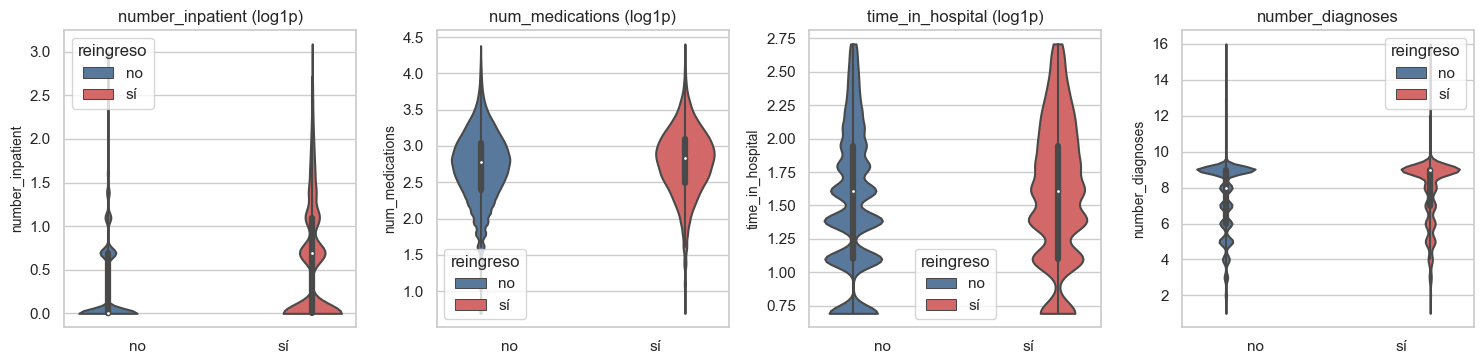

In [3]:
top4 = num_vs["variable"].head(4).tolist()
muestra = frame  # visualización con todo training; no se altera la distribución
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, c in zip(axes, top4):
    d = pd.DataFrame({"reingreso": muestra[TARGET].map({0: "no", 1: "sí"}), c: np.log1p(muestra[c].clip(lower=0)) if frame[c].skew() > 1 else muestra[c]})
    sns.violinplot(data=d, x="reingreso", y=c, hue="reingreso", legend=False, cut=0, ax=ax, palette=["#4c78a8", "#e45756"], order=["no", "sí"], hue_order=["no", "sí"])
    ax.set_title(c + (" (log1p)" if frame[c].skew() > 1 else "")); ax.set_xlabel("")
plt.tight_layout(); save_figure(fig, "05_violines_numericas.png"); plt.show()

## Variables categóricas frente al objetivo

Para cada categórica: χ² de independencia y **V de Cramér** con corrección de sesgo (0 = independientes; 1 = asociación perfecta).
Los códigos de diagnóstico crudos se sustituyen por sus grupos clínicos; las medicaciones casi constantes se conservan en la tabla.

In [4]:
cats = [c for c in cat_cols if c not in ("diag_1", "diag_2", "diag_3")]
rows = []
for c in cats:
    v, chi2, p = cramers_v(frame[c], y)
    rows.append({"variable": c, "niveles": frame[c].nunique(dropna=True), "V de Cramér": v, "chi2": chi2, "p_valor": p})
cat_vs = pd.DataFrame(rows)
cat_vs["p_fdr"] = fdr_bh(cat_vs["p_valor"])
cat_vs = cat_vs.sort_values("V de Cramér", ascending=False).reset_index(drop=True)
cat_vs.to_csv(TABLES / "categoricas_vs_objetivo.csv", index=False)
display(cat_vs.head(15).round(4))
md_out(f"Las categóricas más asociadas son " + ", ".join(f"**{r.variable}** (V = {es(r['V de Cramér'], 3)})" for _, r in cat_vs.head(3).iterrows()) +
       f". **{int((cat_vs['p_fdr'] < 0.05).sum())} de {len(cat_vs)}** son significativas tras FDR; " 
       f"{'ninguna' if (cat_vs['V de Cramér'] >= 0.10).sum() == 0 else 'solo ' + str(int((cat_vs['V de Cramér'] >= 0.10).sum()))} tiene V ≥ 0,10 (asociación moderada o mayor).")

,variable,niveles,V de Cramér,chi2,p_valor,p_fdr
0,discharge_disposition_id,26,0.1186,1170.9809,0.0000,0.0000
1,medical_specialty,70,0.0516,286.8979,0.0000,0.0000
2,insulin,4,0.0419,145.8667,0.0000,0.0000
3,age,10,0.0329,96.9153,0.0000,0.0000
4,diag_1_grupo,10,0.0281,73.5095,0.0000,0.0000
5,diag_3_grupo,10,0.0278,71.8661,0.0000,0.0000
6,payer_code,17,0.0270,76.2382,0.0000,0.0000
7,diabetesMed,2,0.0255,53.7694,0.0000,0.0000
8,metformin,4,0.0218,41.8360,0.0000,0.0000
9,diag_2_grupo,10,0.0194,39.6637,0.0000,0.0000


Las categóricas más asociadas son **discharge_disposition_id** (V = 0,119), **medical_specialty** (V = 0,052), **insulin** (V = 0,042). **16 de 39** son significativas tras FDR; solo 1 tiene V ≥ 0,10 (asociación moderada o mayor).

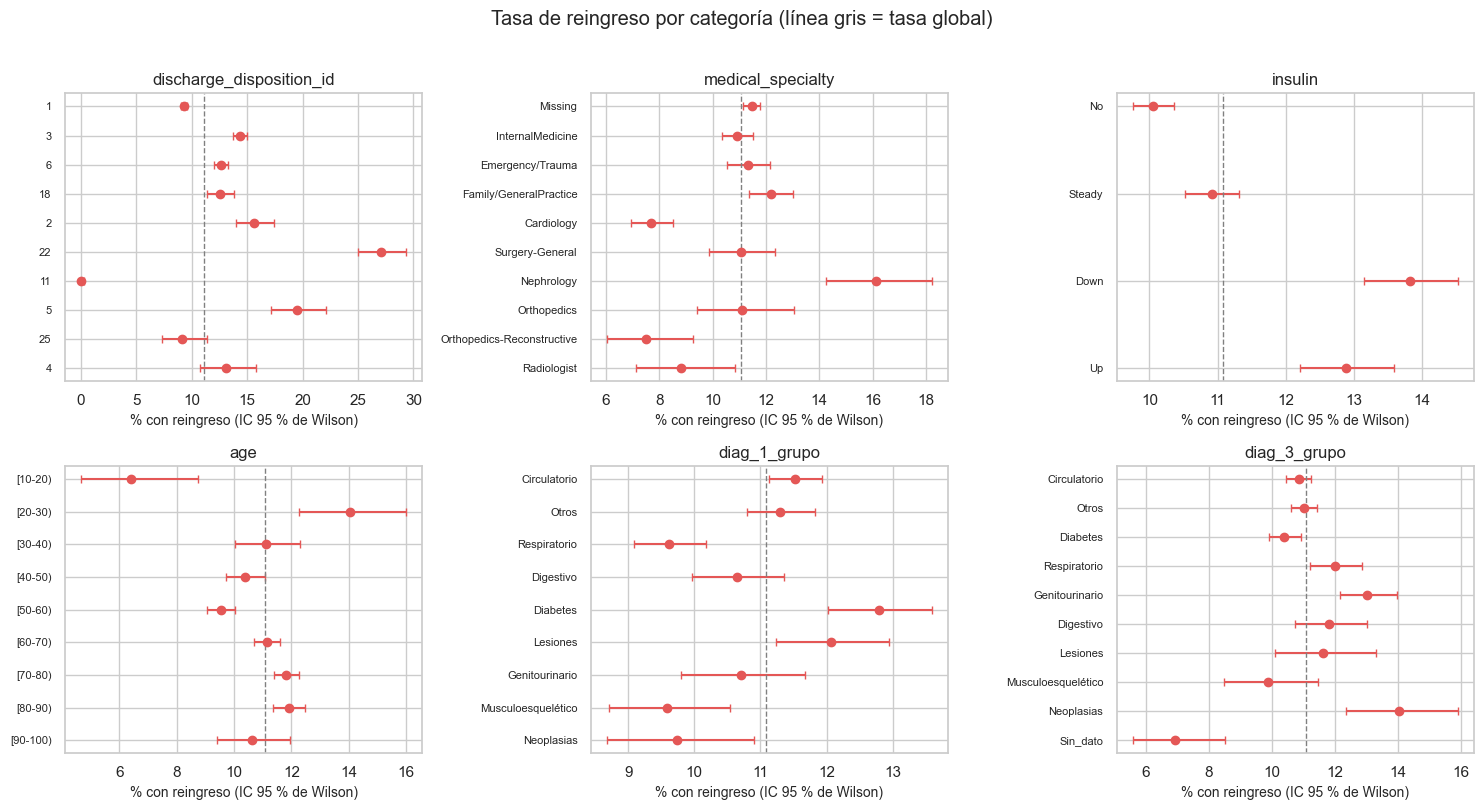

In [5]:
top_cat = cat_vs["variable"].head(6).tolist()
base = y.mean()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), top_cat):
    t = rate_table(frame[c], y, min_n=200, top=10)
    if c == "age":                                   # las edades se ordenan por rango, no por frecuencia
        t = t.sort_values("categoria", key=lambda s: s.str.extract(r"(\d+)")[0].astype(float))
    t = t.iloc[::-1]
    ax.errorbar(t["tasa"] * 100, range(len(t)), xerr=[(t["tasa"] - t["ic_inf"]) * 100, (t["ic_sup"] - t["tasa"]) * 100], fmt="o", color="#e45756", capsize=3)
    ax.axvline(base * 100, color="gray", ls="--", lw=1)
    ax.set_yticks(range(len(t))); ax.set_yticklabels(t["categoria"], fontsize=8)
    ax.set_title(c); ax.set_xlabel("% con reingreso (IC 95 % de Wilson)")
plt.suptitle("Tasa de reingreso por categoría (línea gris = tasa global)", y=1.01)
plt.tight_layout(); save_figure(fig, "05_tasas_por_categoria.png"); plt.show()

## Relaciones entre predictoras: ejemplos representativos

Estos análisis complementan la relación con el target sin producir cientos
de gráficos. Se usan todas las filas de training disponibles.

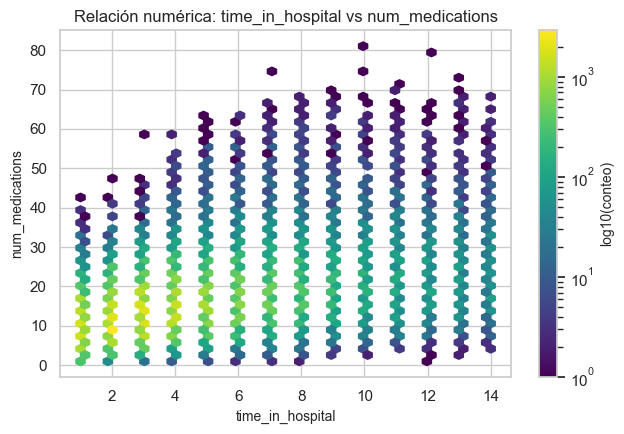

El par numérico con mayor |Spearman| es `time_in_hospital`–`num_medications`: Pearson = 0,469 y Spearman = 0,467. La diferencia entre ambas medidas ayuda a detectar relaciones monotónicas no estrictamente lineales.

In [6]:
# Numérica vs numérica: par con mayor asociación monotónica.
corr_s = frame[num_cols].corr(method="spearman")
upper = corr_s.where(np.triu(np.ones(corr_s.shape), k=1).astype(bool)).stack()
num_a, num_b = upper.abs().idxmax()
pair = frame[[num_a, num_b]].dropna()
fig, ax = plt.subplots(figsize=(6.5, 4.5))
hb = ax.hexbin(pair[num_a], pair[num_b], gridsize=45, bins="log", mincnt=1, cmap="viridis")
fig.colorbar(hb, ax=ax, label="log10(conteo)")
ax.set(title=f"Relación numérica: {num_a} vs {num_b}", xlabel=num_a, ylabel=num_b)
plt.tight_layout(); save_figure(fig, "05_hexbin_numericas.png"); plt.show()
md_out(f"El par numérico con mayor |Spearman| es `{num_a}`–`{num_b}`: Pearson = {es(frame[num_a].corr(frame[num_b], method='pearson'), 3)} y Spearman = {es(corr_s.loc[num_a, num_b], 3)}. La diferencia entre ambas medidas ayuda a detectar relaciones monotónicas no estrictamente lineales.")

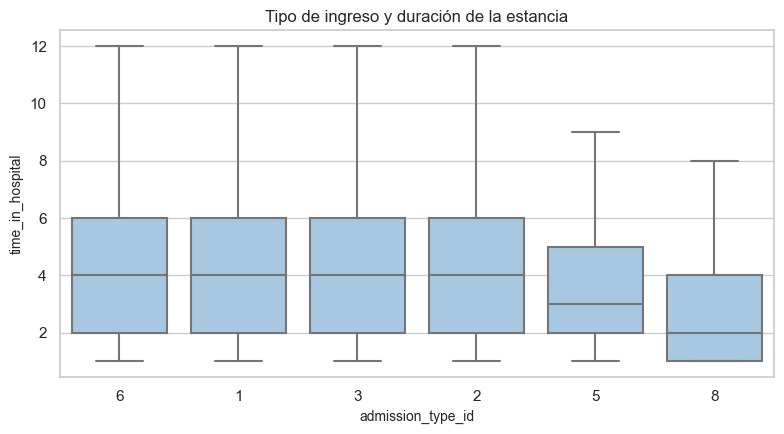

Kruskal–Wallis para `time_in_hospital` según `admission_type_id`: H=304,71, p=9.73e-64, epsilon²=0,004. La significancia se interpreta junto con epsilon², que cuantifica la magnitud práctica.

In [7]:
# Categórica vs numérica: Kruskal-Wallis y epsilon cuadrado.
cat_demo, num_demo = "admission_type_id", "time_in_hospital"
demo = frame[[cat_demo, num_demo]].dropna().copy()
valid_levels = demo[cat_demo].value_counts()[lambda s: s >= 200].index
demo = demo[demo[cat_demo].isin(valid_levels)]
arrays = [g[num_demo].to_numpy() for _, g in demo.groupby(cat_demo, observed=False)]
h_kw, p_kw = stats.kruskal(*arrays)
k_kw, n_kw = len(arrays), len(demo)
epsilon2 = max(0.0, (h_kw - k_kw + 1) / (n_kw - k_kw))
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=demo, x=cat_demo, y=num_demo, showfliers=False, ax=ax, color="#9ecae9")
ax.set_title("Tipo de ingreso y duración de la estancia")
plt.tight_layout(); save_figure(fig, "05_categorica_numerica.png"); plt.show()
md_out(f"Kruskal–Wallis para `{num_demo}` según `{cat_demo}`: H={es(h_kw, 2)}, p={p_kw:.2e}, epsilon²={es(epsilon2, 3)}. La significancia se interpreta junto con epsilon², que cuantifica la magnitud práctica.")

In [8]:
# Categórica vs categórica: contingencia, chi-cuadrado y V de Cramér.
cat_a, cat_b = "change", "diabetesMed"
contingency = pd.crosstab(frame[cat_a], frame[cat_b], margins=True)
v_demo, chi_demo, p_demo = cramers_v(frame[cat_a], frame[cat_b])
display(contingency)
md_out(f"La relación `{cat_a}`–`{cat_b}` tiene χ²={es(chi_demo, 2)}, p={p_demo:.2e} y V de Cramér={es(v_demo, 3)}. V de Cramér, no solo el p-value, indica la intensidad de la asociación.")

diabetesMed,No,Yes,All
change,,,
Ch,0,37663,37663
No,18745,25005,43750
All,18745,62668,81413


La relación `change`–`diabetesMed` tiene χ²=20.963,81, p=0.00e+00 y V de Cramér=0,507. V de Cramér, no solo el p-value, indica la intensidad de la asociación.

## Ranking unificado de variables (selección preliminar)

Para comparar numéricas y categóricas en la misma escala se calcula el **AUC univariado** de cada una: directo para las numéricas, y para
las categóricas codificándolas con la tasa del objetivo calculada **fuera de pliegue** (por paciente), de modo que el AUC no sea optimista.

,variable,tipo,AUC univariado
0,number_inpatient,numérica,0.6096
1,discharge_disposition_id,categórica,0.5748
2,num_medications,numérica,0.5431
3,time_in_hospital,numérica,0.5429
4,number_diagnoses,numérica,0.5406
5,number_emergency,numérica,0.5328
6,insulin,categórica,0.5309
7,medical_specialty,categórica,0.5286
8,number_outpatient,numérica,0.5226
9,age,categórica,0.5219


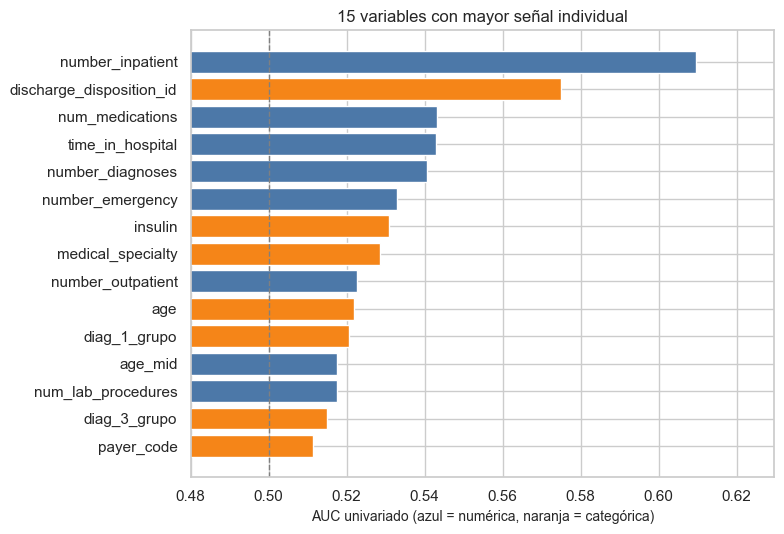

La mayor señal individual es de **number_inpatient** con AUC 0,610. Solo 1 supera 0,60. **Ninguna variable separa por sí sola las clases**: el problema es difícil y cualquier modelo tendrá que combinar muchas señales débiles.

In [9]:
groups = frame[GROUP_COL]
rk = [{"variable": r["variable"], "tipo": "numérica", "AUC univariado": r["AUC univariado"]} for _, r in num_vs.iterrows()]
for c in cats:
    if frame[c].nunique(dropna=True) <= 1:
        continue
    rk.append({"variable": c, "tipo": "categórica", "AUC univariado": categorical_auc_oof(frame[c], y, groups)})
ranking = pd.DataFrame(rk).sort_values("AUC univariado", ascending=False).reset_index(drop=True)
ranking.to_csv(TABLES / "ranking_univariado.csv", index=False)
display(ranking.head(15).round(4))

fig, ax = plt.subplots(figsize=(8, 5.5))
t = ranking.head(15).iloc[::-1]
ax.barh(t["variable"], t["AUC univariado"], color=np.where(t["tipo"] == "numérica", "#4c78a8", "#f58518"))
ax.axvline(0.5, color="gray", ls="--", lw=1); ax.set_xlim(0.48, max(0.6, t["AUC univariado"].max() + 0.02))
ax.set_xlabel("AUC univariado (azul = numérica, naranja = categórica)"); ax.set_title("15 variables con mayor señal individual")
plt.tight_layout(); save_figure(fig, "05_ranking_univariado.png"); plt.show()
md_out(f"La mayor señal individual es de **{ranking.loc[0, 'variable']}** con AUC {es(ranking.loc[0, 'AUC univariado'], 3)}. "
       f"{'Ninguna' if (ranking['AUC univariado'] >= 0.60).sum() == 0 else 'Solo ' + str(int((ranking['AUC univariado'] >= 0.60).sum()))} supera 0,60. "
       + ("**Ninguna variable separa por sí sola las clases**: el problema es difícil y cualquier modelo tendrá que combinar muchas señales débiles."
          if ranking.loc[0, 'AUC univariado'] < 0.75 else
          "Hay variables con señal individual fuerte: se revisan en el capítulo 7 por si son fuga de datos."))

## Información mutua

La información mutua detecta dependencias potencialmente no lineales. Se
calcula sobre todo training, sin usar test ni muestrear filas. Su escala no
implica causalidad y se utiliza como ranking exploratorio.

In [10]:
from sklearn.feature_selection import mutual_info_classif

mi_rows = []
for c in num_cols:
    values = frame[c].fillna(frame[c].median()).to_numpy().reshape(-1, 1)
    value = mutual_info_classif(values, y, discrete_features=False, random_state=RANDOM_STATE)[0]
    mi_rows.append({"variable": c, "tipo": "numérica", "información_mutua": value})
for c in cats:
    values = pd.factorize(frame[c].astype("object").where(frame[c].notna(), "Missing"), sort=True)[0].reshape(-1, 1)
    value = mutual_info_classif(values, y, discrete_features=True, random_state=RANDOM_STATE)[0]
    mi_rows.append({"variable": c, "tipo": "categórica", "información_mutua": value})
mi_table = pd.DataFrame(mi_rows).sort_values("información_mutua", ascending=False).reset_index(drop=True)
mi_table.to_csv(TABLES / "informacion_mutua.csv", index=False)
display(mi_table.head(15).round(5))
md_out("Las mayores estimaciones corresponden a " + ", ".join(
    f"`{r.variable}` ({r.información_mutua:.4f})" for _, r in mi_table.head(3).iterrows()
) + ". El ranking es complementario a AUC y V de Cramér; no demuestra efecto causal ni fuga.")

,variable,tipo,información_mutua
0,number_diagnoses,numérica,0.00904
1,number_inpatient,numérica,0.00773
2,discharge_disposition_id,categórica,0.00708
3,num_lab_procedures,numérica,0.00595
4,num_medications,numérica,0.00531
5,time_in_hospital,numérica,0.00455
6,num_procedures,numérica,0.00265
7,number_emergency,numérica,0.00255
8,age_mid,numérica,0.00231
9,medical_specialty,categórica,0.00194


Las mayores estimaciones corresponden a `number_diagnoses` (0.0090), `number_inpatient` (0.0077), `discharge_disposition_id` (0.0071). El ranking es complementario a AUC y V de Cramér; no demuestra efecto causal ni fuga.